In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel("/content/cleaned_crops.xlsx")
df.head()


,Crop,ScientificName,Symbol,NuContAvailable,PlantPartHarvested,CropCategory,YieldUnit,AvYieldUnitWeight(lb),AvMoisture%,AvN%(dry),AvP%(dry),AvK%(dry)
0,Acorn,Quercus sp.,QUERC,"N,P,K",Fruit,Tree and fruit,lb of fruit,1.0,27.90,1.3647711512,0.10957004161,0.74757281553
1,"Alfalfa + Orchardgrass, for hay","Medicago sativa, Dactylis glomerata","MESA, DAGL","N,P",Aboveground biomass,Forage,ton,2000.0,9.70,2.4797142857,0.26785714286,#DIV/0!
2,"Alfalfa + Orchardgrass, for hay (cut 1)","Medicago sativa, Dactylis glomerata","MESA, DAGL","N,P,K",Aboveground biomass,Forage,ton,2000.0,7.95,2.144,0.2,1.49
3,"Alfalfa + Smooth Brome, for green chop","Medicago sativa, Bromus inermis","MESA, BRIN2","N,P,K",Aboveground biomass,Forage,ton,2000.0,77.63,3.3220740741,0.31055555556,2.8
4,"Alfalfa + Smooth Brome, for hay","Medicago sativa, Bromus inermis","MESA, BRIN2","N,P,K",Aboveground biomass,Forage,ton,2000.0,11.58,2.4177085202,0.27105381166,1.8977466368


In [2]:
# Remove repeated rows
df = df.drop_duplicates()

# Remove rows missing essential identifiers
df = df.dropna(subset=['ScientificName', 'Symbol'])

# Convert numeric columns properly
numeric_cols = ['AvMoisture%', 'AvN%(dry)', 'AvP%(dry)', 'AvK%(dry)']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 711 entries, 0 to 736
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Crop                   711 non-null    object 
 1   ScientificName         711 non-null    object 
 2   Symbol                 711 non-null    object 
 3   NuContAvailable        711 non-null    object 
 4   PlantPartHarvested     711 non-null    object 
 5   CropCategory           711 non-null    object 
 6   YieldUnit              711 non-null    object 
 7   AvYieldUnitWeight(lb)  711 non-null    float64
 8   AvMoisture%            711 non-null    float64
 9   AvN%(dry)              711 non-null    float64
 10  AvP%(dry)              711 non-null    float64
 11  AvK%(dry)              711 non-null    float64
dtypes: float64(5), object(7)
memory usage: 72.2+ KB


In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['CropCategory_encoded'] = le.fit_transform(df['CropCategory'])

X = df[['AvMoisture%', 'AvN%(dry)', 'AvP%(dry)', 'AvK%(dry)']]
y = df['CropCategory_encoded']

df.head()


,Crop,ScientificName,Symbol,NuContAvailable,PlantPartHarvested,CropCategory,YieldUnit,AvYieldUnitWeight(lb),AvMoisture%,AvN%(dry),AvP%(dry),AvK%(dry),CropCategory_encoded
0,Acorn,Quercus sp.,QUERC,"N,P,K",Fruit,Tree and fruit,lb of fruit,1.0,27.90,1.364771,0.109570,0.747573,3
1,"Alfalfa + Orchardgrass, for hay","Medicago sativa, Dactylis glomerata","MESA, DAGL","N,P",Aboveground biomass,Forage,ton,2000.0,9.70,2.479714,0.267857,1.779199,2
2,"Alfalfa + Orchardgrass, for hay (cut 1)","Medicago sativa, Dactylis glomerata","MESA, DAGL","N,P,K",Aboveground biomass,Forage,ton,2000.0,7.95,2.144000,0.200000,1.490000,2
3,"Alfalfa + Smooth Brome, for green chop","Medicago sativa, Bromus inermis","MESA, BRIN2","N,P,K",Aboveground biomass,Forage,ton,2000.0,77.63,3.322074,0.310556,2.800000,2
4,"Alfalfa + Smooth Brome, for hay","Medicago sativa, Bromus inermis","MESA, BRIN2","N,P,K",Aboveground biomass,Forage,ton,2000.0,11.58,2.417709,0.271054,1.897747,2


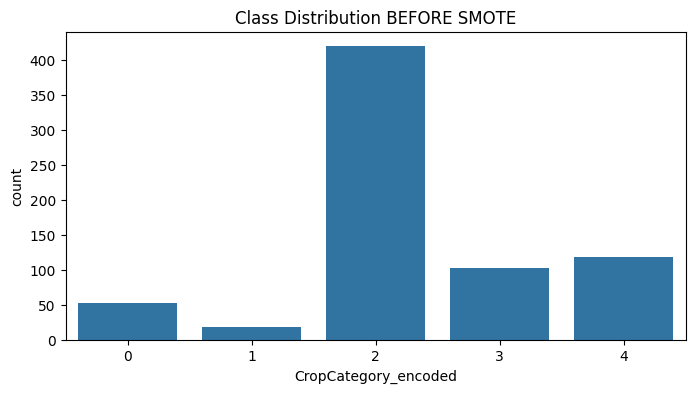

In [4]:
plt.figure(figsize=(8,4))
sns.countplot(x=y)
plt.title("Class Distribution BEFORE SMOTE")
plt.show()


In [5]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_smote, y_smote = sm.fit_resample(X, y)

print("Before SMOTE:", X.shape)
print("After SMOTE:", X_smote.shape)


Before SMOTE: (711, 4)
After SMOTE: (2100, 4)


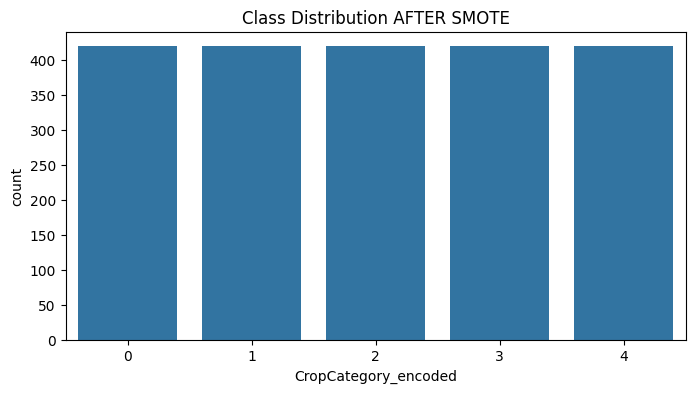

In [6]:
plt.figure(figsize=(8,4))
sns.countplot(x=y_smote)
plt.title("Class Distribution AFTER SMOTE")
plt.show()


In [7]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_smote)

X_scaled[:5]  # show first few rows


array([[0.27048741, 0.20352993, 0.0761655 , 0.08819274],
       [0.07552223, 0.37420473, 0.20501033, 0.24490337],
       [0.05677558, 0.3228138 , 0.14977499, 0.2009722 ],
       [0.80321371, 0.50315265, 0.2397666 , 0.39996962],
       [0.09566149, 0.36471293, 0.2076124 , 0.26291154]])

In [8]:
final_df = pd.DataFrame(X_scaled, columns=['AvMoisture%', 'AvN%(dry)', 'AvP%(dry)', 'AvK%(dry)'])
final_df['CropCategory_encoded'] = y_smote

final_df.to_excel("final_preprocessed_data.xlsx", index=False)
print("Saved: final_preprocessed_data.xlsx")


Saved: final_preprocessed_data.xlsx


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_smote,
    test_size=0.2,
    random_state=42,
    stratify=y_smote
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Training labels:", np.bincount(y_train))
print("Testing labels:", np.bincount(y_test))


Train shape: (1680, 4)
Test shape: (420, 4)
Training labels: [336 336 336 336 336]
Testing labels: [84 84 84 84 84]


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models = [
    ("Random Forest", RandomForestClassifier(random_state=42)),
    ("Logistic Regression", LogisticRegression(solver='liblinear', random_state=42)),
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    ("KNN", KNeighborsClassifier()),
    ("SVM", SVC(random_state=42))
]

print("Models initialized successfully!")


Models initialized successfully!


In [11]:
print("\n📘 Starting Training of All 5 Models...\n")

trained_models = []  # store fitted models

for name, model in models:
    print(f"🔄 Training {name}...")
    model.fit(X_train, y_train)
    trained_models.append((name, model))
    print(f"✔ {name} trained successfully!\n")

print("🎉 All models trained successfully!")



📘 Starting Training of All 5 Models...

🔄 Training Random Forest...
✔ Random Forest trained successfully!

🔄 Training Logistic Regression...
✔ Logistic Regression trained successfully!

🔄 Training Decision Tree...
✔ Decision Tree trained successfully!

🔄 Training KNN...
✔ KNN trained successfully!

🔄 Training SVM...
✔ SVM trained successfully!

🎉 All models trained successfully!


In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
import pandas as pd

print("\n🔷 Running 5-Fold Cross Validation for All Models...\n")

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

kfold_results = []

for name, model in models:
    print(f"🔄 Running K-Fold for {name}...")
    scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    kfold_results.append([name, scores.mean(), scores.std()])
    print(f"✔ {name} | Mean Accuracy = {scores.mean():.4f}, Std = {scores.std():.4f}\n")

kfold_df = pd.DataFrame(kfold_results, columns=["Model", "Mean Accuracy", "Std Dev"])
display(kfold_df.sort_values(by="Mean Accuracy", ascending=False))



🔷 Running 5-Fold Cross Validation for All Models...

🔄 Running K-Fold for Random Forest...
✔ Random Forest | Mean Accuracy = 0.9054, Std = 0.0158

🔄 Running K-Fold for Logistic Regression...
✔ Logistic Regression | Mean Accuracy = 0.5625, Std = 0.0098

🔄 Running K-Fold for Decision Tree...
✔ Decision Tree | Mean Accuracy = 0.8554, Std = 0.0262

🔄 Running K-Fold for KNN...
✔ KNN | Mean Accuracy = 0.8560, Std = 0.0220

🔄 Running K-Fold for SVM...
✔ SVM | Mean Accuracy = 0.7512, Std = 0.0187



,Model,Mean Accuracy,Std Dev
0,Random Forest,0.905357,0.015793
3,KNN,0.855952,0.022000
2,Decision Tree,0.855357,0.026190
4,SVM,0.751190,0.018691
1,Logistic Regression,0.562500,0.009781


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics_list = []

print("\n📘 Evaluating All 5 Models on Test Set...\n")

for name, model in trained_models:
    y_pred = model.predict(X_test)

    metrics_list.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_pred, average='weighted', zero_division=0)
    ])

metrics_df = pd.DataFrame(metrics_list, columns=[
    "Model", "Accuracy", "Precision (Weighted)", "Recall (Weighted)", "F1 Score (Weighted)"
])

metrics_df



📘 Evaluating All 5 Models on Test Set...



,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1 Score (Weighted)
0,Random Forest,0.921429,0.921572,0.921429,0.920902
1,Logistic Regression,0.576190,0.542331,0.576190,0.524167
2,Decision Tree,0.902381,0.903645,0.902381,0.901668
3,KNN,0.859524,0.863400,0.859524,0.859825
4,SVM,0.723810,0.737044,0.723810,0.723676


In [14]:
display(
    metrics_df.style.background_gradient(cmap="Blues").format({
        "Accuracy": "{:.2%}",
        "Precision (Weighted)": "{:.2%}",
        "Recall (Weighted)": "{:.2%}",
        "F1 Score (Weighted)": "{:.2%}"
    })
)


,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1 Score (Weighted)
0,Random Forest,92.14%,92.16%,92.14%,92.09%
1,Logistic Regression,57.62%,54.23%,57.62%,52.42%
2,Decision Tree,90.24%,90.36%,90.24%,90.17%
3,KNN,85.95%,86.34%,85.95%,85.98%
4,SVM,72.38%,73.70%,72.38%,72.37%


In [15]:
# 🔮 FINAL PREDICTION FUNCTION — RETURNS CATEGORY NAME

def predict_crop_category(model, scaler, input_values):
    """
    input_values should be a list like:
    [AvMoisture%, AvN%(dry), AvP%(dry), AvK%(dry)]
    """

    # Convert to DataFrame
    import pandas as pd
    input_df = pd.DataFrame([input_values], columns=['AvMoisture%', 'AvN%(dry)', 'AvP%(dry)', 'AvK%(dry)'])

    # Scale the input using the same scaler used before
    input_scaled = scaler.transform(input_df)

    # Predict encoded label
    encoded_pred = model.predict(input_scaled)[0]

    # Convert encoded label back to category name
    category_name = le.inverse_transform([encoded_pred])[0]

    return category_name


# ⭐ Example custom input
custom_input = [10.5, 2.3, 0.25, 1.7]     # Change values as needed

# ⭐ Select the best model (Example: Random Forest)
best_model = trained_models[0][1]   # Or manually select one

predicted_name = predict_crop_category(best_model, scaler, custom_input)

print("Input values:", custom_input)
print("Predicted Crop Category:", predicted_name)


Input values: [10.5, 2.3, 0.25, 1.7]
Predicted Crop Category: Forage
